[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jalonso1979/puremacro/blob/main/curso/notebooks/T06_B_life_cycle_and_demographics_es.ipynb)

> **Nota para Google Colab**: la celda siguiente instala `puremacro` y, si hace falta, descarga del repositorio público [jalonso1979/puremacro](https://github.com/jalonso1979/puremacro) sólo la carpeta `curso/notebooks` (auxiliares, datos congelados y modelos). No pide acceso a Google Drive.

In [1]:
# Configuración del entorno: Google Colab, instalación local o Juno (iPad)
import os
import sys
from pathlib import Path

def _safe_probe(p, is_dir=None):
    """¿Existe la ruta? Sin lanzar OSError/PermissionError en el sandbox de Juno."""
    try:
        p = Path(p)
        if is_dir is True:
            return p.is_dir()
        if is_dir is False:
            return p.is_file()
        return p.exists()
    except (OSError, PermissionError, TypeError, ValueError):
        return False

if "google.colab" in sys.modules:
    !pip install -q "puremacro>=4.0.1,<5" openpyxl
    if not _safe_probe(Path.cwd() / "_nbstyle.py", is_dir=False):
        # Clon parcial del repositorio público: sólo curso/notebooks, sin historia
        _repo = Path("/content/puremacro")
        if not _safe_probe(_repo, is_dir=True):
            !git clone -q --depth 1 --filter=blob:none --sparse https://github.com/jalonso1979/puremacro.git {_repo}
        !git -C {_repo} sparse-checkout set curso/notebooks 2>&1 | tail -n 2
        os.chdir(_repo / "curso/notebooks")

# Carpeta con los auxiliares del curso (_nbstyle, _datos) en sys.path, sin salir del sandbox
_candidatos = [Path.cwd(), Path.cwd() / "notebooks", Path.cwd() / "curso/notebooks"]
try:
    _candidatos.insert(0, Path(__file__).resolve().parent)  # Juno define __file__
except (NameError, OSError):
    pass
for _c in _candidatos:
    if _safe_probe(_c / "_nbstyle.py", is_dir=False):
        if str(_c) not in sys.path:
            sys.path.insert(0, str(_c))
        break

# Gráficas en línea y estilo del curso
%matplotlib inline
try:
    import _nbstyle
    _nbstyle.apply_style()
except ImportError:
    pass

# Macroeconomía del Ciclo de Vida: Suavizamiento del Consumo, Demografía y Solvencia de Pensiones

¿Por qué acumulan riqueza los hogares? En la macroeconomía contemporánea, las decisiones de ahorro responden a dos funciones económicas esenciales y conceptualmente diferenciadas:
1. **Autoaseguramiento Precautorio**: Amortiguar choques transitorios e inasegurables sobre el ingreso laboral (Bewley 1977, Aiyagari 1994, Carroll 1997).
2. **Reasignación Intertemporal del Ciclo de Vida**: Desplazar recursos a través del tiempo para suavizar el consumo a lo largo de un ciclo vital finito (Modigliani & Brumberg 1954, Friedman 1957, Auerbach & Kotlikoff 1987).

A lo largo de la carrera de un trabajador, la productividad laboral sigue una trayectoria en forma de joroba (U invertida): es reducida durante la juventud debido a la inserción laboral y el proceso inicial de acumulación de capital humano (Becker 1964, Mincer 1974), alcanza su nivel máximo durante los años de madurez laboral y decae bruscamente al alcanzar la jubilación. Si los mercados financieros fuesen completos y careciesen de fricciones, los hogares jóvenes se endeudarían contra sus elevados ingresos futuros para disfrutar de una senda de consumo uniforme. Sin embargo, cuando las restricciones de endeudamiento ($a' \ge 0$) impiden monetizar la riqueza humana futura, los jóvenes se encuentran restringidos por liquidez: consumen prácticamente todo su ingreso corriente, acumulan activos únicamente cuando sus salarios crecen, alcanzan un colchón máximo de riqueza en vísperas del retiro y posteriormente desacumulan activos hasta el final de la vida.

En este cuaderno, resolvemos formalmente el problema dinámico de consumo y ahorro de un hogar con horizonte temporal finito sujeto a riesgo laboral inasegurable e incertidumbre de supervivencia. Analizamos la distribución de riqueza transversal de las cohortes, agregamos el capital bajo distintas pirámides demográficas y llevamos a cabo un experimento empírico de política macroeconómica: simulamos un **choque de envejecimiento demográfico** empleando microdatos empíricos de salarios de la Oficina de Estadísticas Laborales de EE. UU. (BLS) y series demográficas históricas para cuantificar el desbalance fiscal en sistemas de reparto (PAYGO) y evaluar el **trilema de política pública del envejecimiento**.

## Fundamentos Teóricos: Marco OLG de Horizonte Finito, Jorobas Salariales y Riesgo de Mortalidad

### 1. Demografía, Riesgo de Supervivencia e Incompletitud de Anualidades
Un hogar entra en la vida laboral activa en la edad de modelo $j = 0$ (correspondiente a la edad cronológica de 25 años) y vive hasta una edad máxima de $J-1$ (aquí $J = 40$, representativo de los 64/65 años). En cada edad $j$, el agente enfrenta una probabilidad condicional de supervivencia $s_j \in (0, 1]$, que denota la probabilidad de sobrevivir hasta la edad $j+1$ condicional a estar vivo en $j$, con certeza absoluta de defunción terminal $s_{J-1} = 0$.

En ausencia de mercados privados de anualidades actuarialmente justas (Yaari 1965), los hogares enfrentan riesgo de mortalidad no asegurable. Por ende, el factor de descuento subjetivo aplicado al valor de continuación del período siguiente incorpora la probabilidad de supervivencia:
$$ \beta_j^{\text{eff}} = \beta s_j. $$
Si un individuo fallece antes de la edad $J-1$ manteniendo un saldo positivo de activos, dicho patrimonio constituye una **herencia accidental**.

### 2. Problema Dinámico del Hogar e Inducción Hacia Atrás
En cada edad $j \in \{0, 1, \dots, J-1\}$, un hogar con tenencias corrientes de activos $a \ge 0$ y estado de productividad laboral $z \in \mathcal{Z}$ resuelve la ecuación de Bellman:
$$ V_j(a, z) = \max_{a' \ge 0} \left\{ u(c) + \beta s_j \mathbb{E}\!\left[V_{j+1}(a', z') \mid z\right] \right\} $$
sujeta a la restricción presupuestaria de flujo y la cota de endeudamiento:
$$ c + a' = \kappa_j e^z + (1+r) a, \qquad a' \ge 0, $$
con funciones de utilidad con Aversión Relativa al Riesgo Constante (CRRA):
$$ u(c) = \frac{c^{1-\gamma} - 1}{1-\gamma}, \qquad \gamma > 0. $$

**La Condición Terminal**: En el período final de vida $j = J-1$, el hogar conoce con certidumbre que no sobrevivirá al período $J$. Al no existir motivo de legado altruista, el valor de continuación futuro es idénticamente nulo:
$$ V_J(a', z') \equiv 0 \quad \forall (a', z'). $$
Por consiguiente, en $j = J-1$, el hogar fija $a' = 0$ y consume todos los recursos disponibles restantes:
$$ c_{J-1}(a, z) = \kappa_{J-1} e^z + (1+r) a. $$

A diferencia de los modelos de horizonte infinito (como Aiyagari o Huggett), este problema dinámico **no constituye una contracción de punto fijo**. Al conocerse de antemano el valor terminal $V_J$, el modelo se resuelve de manera exacta y determinista mediante **inducción hacia atrás** en exactamente $J$ etapas, iterando desde $j = J-1$ hacia atrás hasta $j = 0$.

### 3. Descomposición Salarial: Joroba Determinista vs. Riesgo Idiosincrático
El ingreso laboral bruto $y_j(z) = \kappa_j e^z$ se descompone en dos factores económicos bien diferenciados:
1. Un **perfil determinista de productividad del ciclo vital** $\kappa_j = \exp(0.1 j - 0.0025 j^2)$, que reproduce los rendimientos mincerianos a la experiencia laboral y la depreciación cognitiva o física tardía, con su cúspide en la edad de modelo $j^* = 0.1 / (2 \times 0.0025) = 20$.
2. Un **choque estocástico e idiosincrático de productividad laboral** $z$, que sigue un proceso AR(1) estacionario discretizado mediante el método de Tauchen:
   $$ z' = \rho_z z + \sigma_z \varepsilon', \quad \varepsilon' \overset{\text{iid}}{\sim} \mathcal{N}(0, 1). $$

### 4. Dinámica de Riqueza de las Cohortes y Agregación Demográfica
Denotemos por $\mu_j(a, z)$ la distribución conjunta de activos y productividad para los hogares de edad $j$. Cada nueva cohorte entra en $j=0$ con riqueza prácticamente nula $\mu_0$. La masa evoluciona deterministamente a través del operador de política de ahorro $T_j$ y la matriz de transición de Markov $\Pi_z$:
$$ \mu_{j+1} = \Pi_z^\top T_j \mu_j. $$

Para agregar a través de toda la sección transversal de la economía, cada cohorte $j$ es ponderada por su masa poblacional estacionaria $\ell_j$. Dado el crecimiento demográfico neto $n$ y el perfil de supervivencia $s_j$:
$$ \ell_0 = 1, \qquad \ell_{j+1} = \ell_j \frac{s_j}{1+n}, \qquad w_j = \frac{\ell_j}{\sum_{k=0}^{J-1} \ell_k}. $$
El capital agregado per cápita $K$ y la oferta laboral agregada $L$ se obtienen integrando a lo largo de toda la distribución demográfica:
$$ K = \sum_{j=0}^{J-1} w_j \mathbb{E}_j[a] = \sum_{j=0}^{J-1} w_j \int a \, d\mu_j(a, z), \qquad L = \sum_{j=0}^{J-1} w_j \kappa_j \mathbb{E}[e^z]. $$

In [2]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
from _datos import DATOS

_nbstyle.apply_style()

from puremacro.vfi import life_cycle_profile, stationary_age_weights

## 1. Trayectorias de Consumo y Riqueza a lo Largo del Ciclo de Vida

Resolvemos el problema del ciclo de vida de referencia para un horizonte de 40 períodos ($J = 40$) utilizando `life_cycle_profile`. El algoritmo construye una malla de activos de $n_a = 120$ puntos sobre $[0, 40]$ y discretiza el proceso AR(1) de productividad en $n_z = 5$ estados. Ejecuta la inducción hacia atrás desde la edad 39 hasta la 0, calculando las políticas óptimas de consumo, las transiciones de activos y la distribución de cohortes indexada por edad.

In [3]:
lc = life_cycle_profile(horizon=40, n_z=5, n_a=120, a_max=40.0)
assets_by_age = lc["assets_by_age"]
cons_by_age = lc["consumption_by_age"]
dist = lc["life_cycle_dist"]                               # Dimensión: (J, n_a, n_z)
J = assets_by_age.shape[0]
age = np.arange(J)
peak_age = int(assets_by_age.argmax())

print(f"Activos medios máximos: {assets_by_age.max():.2f} en la edad modelo {peak_age} (edad cronológica ~{25 + peak_age})")
print(f"Activos iniciales (edad 0): {assets_by_age[0]:.4f} | Activos finales (edad {J-1}): {assets_by_age[-1]:.4f}")
print(f"Consumo medio: inicial={cons_by_age[0]:.2f}, máximo={cons_by_age.max():.2f}, final={cons_by_age[-1]:.2f}")

assert assets_by_age.max() > assets_by_age[0], "Los activos deben acumularse durante la vida laboral"
assert assets_by_age[-1] < assets_by_age.max(), "Los activos deben desacumularse hacia el retiro"
assert np.all(cons_by_age > 0), "El consumo debe ser estrictamente positivo en todas las edades"

Activos medios máximos: 8.53 en la edad modelo 29 (edad cronológica ~54)
Activos iniciales (edad 0): 0.0000 | Activos finales (edad 39): 1.7327
Consumo medio: inicial=1.22, máximo=3.15, final=3.15


### Anatomía Macroeconómica del Suavizamiento del Consumo: Por Qué los Activos Forman una Joroba

La trayectoria cuantitativa de los activos medios describe la clásica **joroba del ciclo vital**, explicada por tres mecanismos macroeconómicos fundamentales:

1. **Juventud y la Restricción de Endeudamiento Vinculante ($a' \ge 0$)**:
   Los hogares recién nacidos entran al mercado en la edad 0 sin riqueza financiera. Hacia adelante, anticipan un incremento sustancial de sus ingresos conforme acumulan experiencia y capital humano hacia la edad 20. De acuerdo con la Hipótesis del Ingreso Permanente, los jóvenes desearían endeudarse contra su riqueza humana futura para adelantar consumo. No obstante, el endeudamiento sin colateral contra capital humano está institucionalmente vedado ($a' \ge 0$). Por lo tanto, la restricción de endeudamiento opera a plena capacidad en los jóvenes: consumen prácticamente todo su ingreso corriente y su riqueza promedio permanece en cero.

2. **Acumulación en la Madurez: Retiro y Motivo Precautorio**:
   A medida que los trabajadores alcanzan sus 30 y 40 años (edades de modelo 10–25), la productividad laboral $\kappa_j$ alcanza su máximo. Los ingresos corrientes superan ahora con creces el promedio vital. Dos motivos impulsan una rápida acumulación de activos:
   - **Ahorro para el Retiro**: Generar un colchón financiero para sostener el consumo durante la jubilación.
   - **Prudencia de Kimball (1990)**: Autoasegurarse frente a choques persistentes AR(1) en un entorno de mercados incompletos.
   Los activos crecen sostenidamente y alcanzan su nivel más alto en la edad de modelo 29 (edad cronológica ~54), justo en las vísperas del retiro laboral y antes de que los salarios comiencen a desplomarse.

3. **Desacumulación en el Retiro y Ausencia de Legados**:
   A partir de la edad 30, la productividad laboral se contrae y llega el retiro. Debido a que $V_J \equiv 0$ y los agentes no obtienen utilidad de dejar herencias, el patrimonio acumulado es liquidado paulatinamente para financiar el consumo, reduciéndose de forma sistemática hacia la edad terminal.

4. **Suavidad del Consumo**:
   Observe la trayectoria del consumo en contraste con la joroba de ingresos. Mientras la productividad laboral $\kappa_j$ se eleva en más de un 170% entre la edad 0 y la 20 antes de desplomarse, el consumo exhibe una trayectoria notablemente estable y suave a lo largo de todo el ciclo de vida. La acumulación de activos financieros cumple con éxito la función de desacoplar el consumo de la volatilidad del perfil salarial.

### Figura 1: Trayectorias de Activos Medios y Consumo a lo Largo del Ciclo de Vida

El gráfico siguiente ilustra los activos medios y el consumo junto con el perfil determinista de productividad normalizado $\kappa_j$. Observe cómo la riqueza alcanza su cúspide en las vísperas de la jubilación, aislando al consumo de la caída tardía de los ingresos laborales.

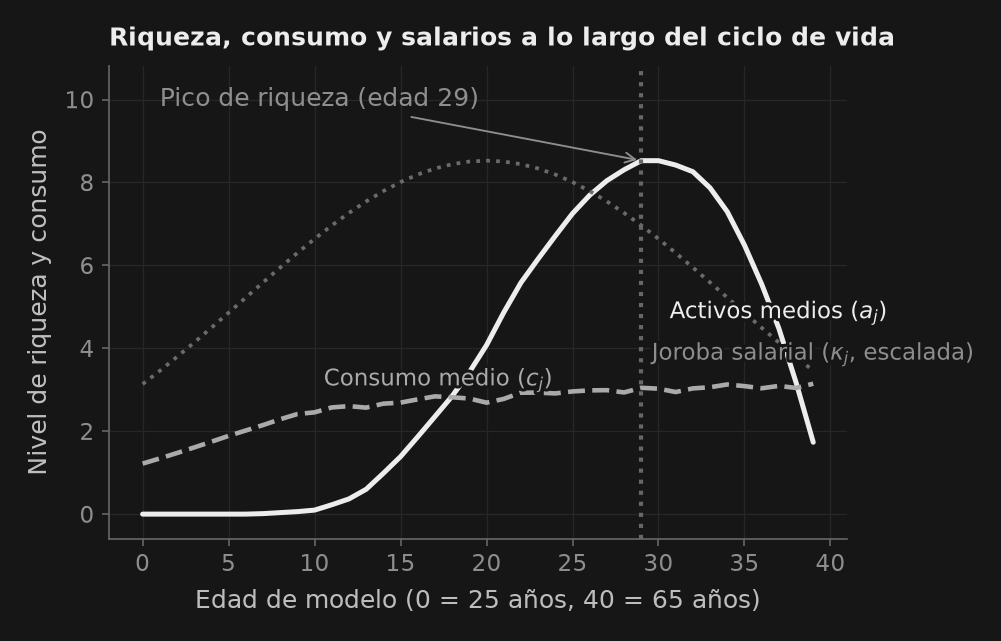

In [4]:
cols = _nbstyle.palette(3)
kappa_profile = np.exp(0.1 * age - 0.0025 * age**2)
kappa_normalized = kappa_profile / kappa_profile.max() * assets_by_age.max()

fig, ax1 = _nbstyle.figura()

ax1.plot(age, assets_by_age, color=cols[0], lw=2.4, ls="-", label="Activos medios ($a_j$)")
ax1.plot(age, cons_by_age, color=cols[1], lw=2.2, ls="--", label="Consumo medio ($c_j$)")
ax1.plot(age, kappa_normalized, color=cols[2], lw=1.8, ls=":", label=r"Joroba salarial ($\kappa_j$, escalada)")
ax1.axvline(peak_age, color=_nbstyle.SPINE, ls=":")

ax1.set_xlabel("Edad de modelo (0 = 25 años, 40 = 65 años)")
ax1.set_ylabel("Nivel de riqueza y consumo")
ax1.set_title("Riqueza, consumo y salarios a lo largo del ciclo de vida")
ax1.set_ylim(-0.6, 10.8)
ax1.annotate(f"Pico de riqueza (edad {peak_age})",
             xy=(peak_age, assets_by_age.max()), xytext=(1.0, 10.0),
             arrowprops=_nbstyle.FLECHA, color=_nbstyle.NOTA, va="center")
_nbstyle.etiquetar(ax1)

plt.show()


### Figura 2: Evolución de la Distribución Transversal de Riqueza por Cohortes

El mapa de calor ilustra la distribución transversal completa de activos $\mu_j(a)$ para cada cohorte de edad $j$ (marginalizada sobre la productividad $z$). En la juventud (edades 0–5), la masa está concentrada en la cota $a=0$. Conforme las cohortes envejecen, la distribución se expande hacia patrimonios más elevados: las trayectorias de choques individuales divergen, generando notable desigualdad intracohorte. Al final de la vida, la distribución se contrae nuevamente hacia cero conforme los hogares desahorran.

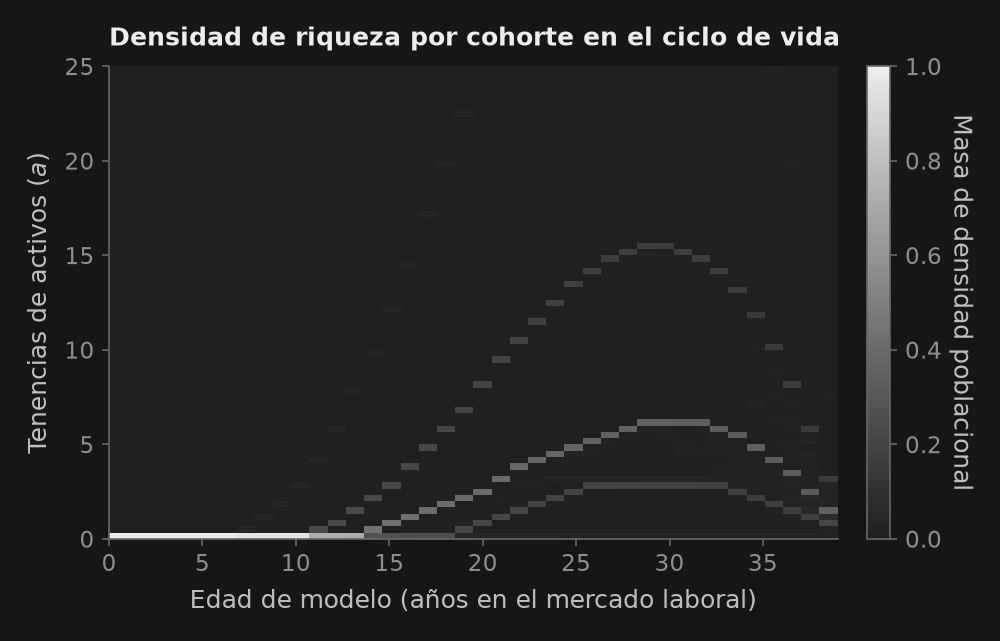

In [5]:
dist_a = dist.sum(axis=2)                                 # Dimensión: (J, n_a), distribución marginal sobre z
a_grid = np.linspace(0.0, 40.0, dist_a.shape[1])

fig, ax = _nbstyle.figura()
im = ax.imshow(dist_a.T, origin="lower", aspect="auto", cmap=_nbstyle.CMAP_SEQ,
               extent=[0, J - 1, a_grid[0], a_grid[-1]])
ax.set_ylim(0, 25)
ax.grid(False)
ax.set_xlabel("Edad de modelo (años en el mercado laboral)")
ax.set_ylabel("Tenencias de activos ($a$)")
ax.set_title("Densidad de riqueza por cohorte en el ciclo de vida")
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Masa de densidad poblacional", rotation=270, labelpad=15)

plt.show()


## 2. Agregación Demográfica: Pirámides Poblacionales y Capital Agregado

Los agregados macroeconómicos no dependen exclusivamente de las funciones de política individual: dependen decisivamente de cuántos individuos habitan en cada cohorte. En estado estacionario, las participaciones demográficas $w_j$ definen la **pirámide poblacional**:
$$ \ell_0 = 1, \qquad \ell_{j+1} = \ell_j \frac{s_j}{1+n}, \qquad w_j = \frac{\ell_j}{\sum_{k=0}^{J-1} \ell_k}. $$

- **Referencia Demográfica Uniforme ($s_j \equiv 1, n = 0$)**: En ausencia de mortalidad y con tasa de crecimiento cero, cada cohorte posee idéntico peso $w_j = 1/J$.
- **Pirámide con Mortalidad ($s_j < 1$)**: Cuando la supervivencia decae con la edad ($s_j = \text{clip}(1.0 - 0.0015 j, 0.85, 1.0)$), las cohortes mayores son progresivamente menos numerosas.

Dado que la riqueza se concentra en las edades maduras (25–35), la mortalidad reduce la ponderación demográfica de los hogares más ricos. Por consiguiente, una economía con mayor mortalidad exhibe un **menor capital agregado per cápita**:
$$ K_{\text{mortalidad}} = \sum_{j=0}^{J-1} w_j^{\text{mortalidad}} a_j < K_{\text{uniforme}} = \sum_{j=0}^{J-1} \frac{1}{J} a_j. $$

Capital Agregado per Cápita (K):
  Demografía Uniforme (sin mortalidad): K = 3.58
  Demografía con Mortalidad:            K = 2.80
  Brecha de Capital por Mortalidad:     -21.95%


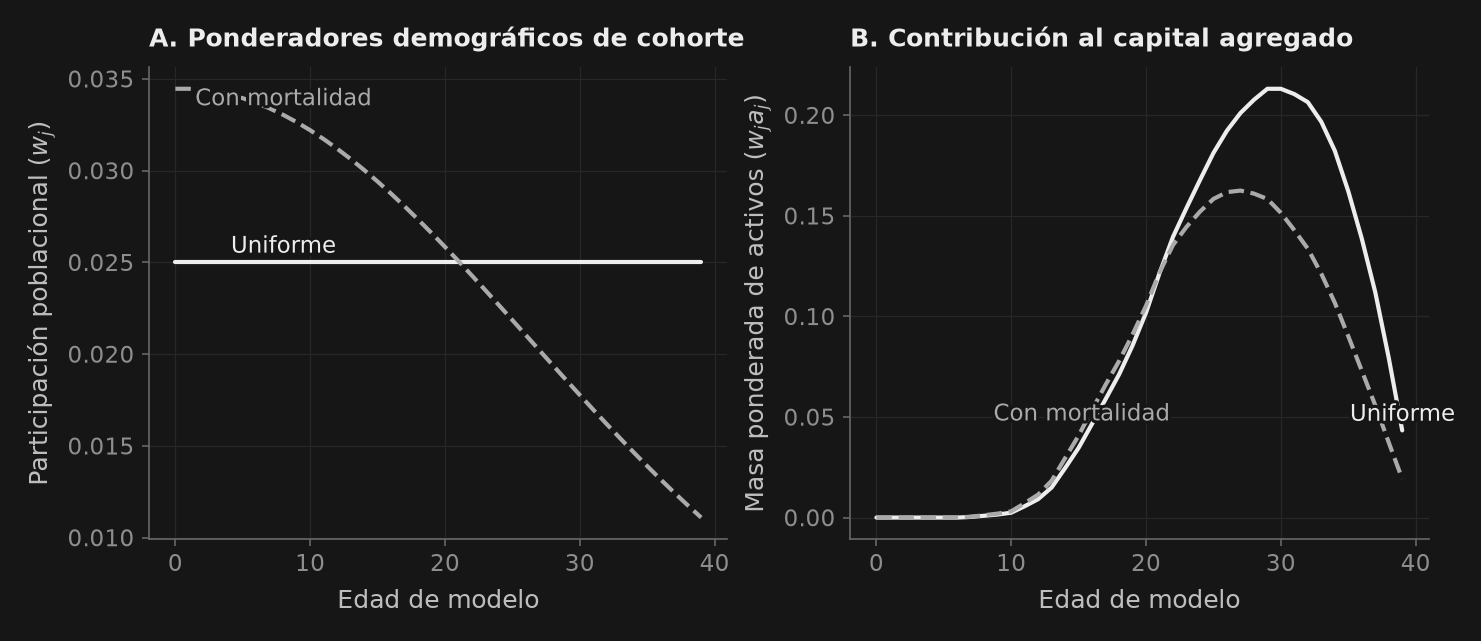

In [6]:
surv = np.clip(1.0 - 0.0015 * age, 0.85, 1.0)
w_uniform = stationary_age_weights(J)                     # Uniforme: 1/J
w_mortality = stationary_age_weights(J, survival=surv)
K_uniform = float(np.sum(w_uniform * assets_by_age))
K_mortality = float(np.sum(w_mortality * assets_by_age))

print("Capital Agregado per Cápita (K):")
print(f"  Demografía Uniforme (sin mortalidad): K = {K_uniform:.2f}")
print(f"  Demografía con Mortalidad:            K = {K_mortality:.2f}")
print(f"  Brecha de Capital por Mortalidad:     {(K_mortality/K_uniform - 1):.2%}")

assert np.isclose(w_uniform.sum(), 1.0) and np.isclose(w_mortality.sum(), 1.0)
assert K_mortality < K_uniform, "La mortalidad debe reducir el capital agregado al adelgazar cohortes ricas en activos"

fig, (a1, a2) = _nbstyle.figura(1, 2)
a1.plot(age, w_uniform, color=cols[0], lw=2, ls="-", label="Uniforme")
a1.plot(age, w_mortality, color=cols[1], lw=2, ls="--", label="Con mortalidad")
a1.set_xlabel("Edad de modelo")
a1.set_ylabel("Participación poblacional ($w_j$)")
a1.set_title("A. Ponderadores demográficos de cohorte")
_nbstyle.etiquetar(a1, donde=8)

a2.plot(age, w_uniform * assets_by_age, color=cols[0], lw=2, ls="-", label="Uniforme")
a2.plot(age, w_mortality * assets_by_age, color=cols[1], lw=2, ls="--", label="Con mortalidad")
a2.set_xlabel("Edad de modelo")
a2.set_ylabel("Masa ponderada de activos ($w_j a_j$)")
a2.set_title("B. Contribución al capital agregado")
_nbstyle.etiquetar(a2)

plt.show()


## 3. Robustez Estructural: Preferencia Temporal ($\beta$) y la Joroba del Ciclo de Vida

¿Qué tan sensible es el perfil de riqueza del ciclo vital respecto al factor de descuento subjetivo $\beta$?
En la ecuación de Euler:
$$ u'(c_j) \ge \beta (1+r) s_j \mathbb{E}\!\left[u'(c_{j+1})\right], $$
el producto $\beta (1+r)$ determina la pendiente intertemporal deseada del consumo. Un hogar más paciente ($\beta = 0.98$ frente al caso base $\beta = 0.96$) otorga mayor valor al consumo futuro, lo que induce una trayectoria de acumulación más pronunciada y una cima de riqueza superior.

Crucialmente, la **forma de joroba interior es estructuralmente invariante a la paciencia**:
- Los hogares jóvenes enfrentan restricciones de endeudamiento ($a' \ge 0$), lo que ancla la riqueza inicial en cero.
- Los hogares en edad avanzada enfrentan un valor terminal nulo ($V_J \equiv 0$), lo que exige desacumular la riqueza antes del período final.
- En consecuencia, para cualquier factor de descuento admisible $\beta \in (0, 1)$, el pico de riqueza ocurre estrictamente en el interior: $0 < j_{\text{pico}} < J-1$.

In [7]:
beta_you = 0.98
lc_you = life_cycle_profile(horizon=40, n_z=5, n_a=120, a_max=40.0, beta=beta_you)
assets_you = lc_you["assets_by_age"]
peak_age_you = int(assets_you.argmax())

print(f"Análisis de Sensibilidad a la Paciencia:")
print(f"  Línea Base (beta=0.96): Activos pico = {assets_by_age.max():.2f} en edad {peak_age}")
print(f"  Paciente   (beta=0.98): Activos pico = {assets_you.max():.2f} en edad {peak_age_you}")

# Verificación estructural: el pico es estrictamente interior y el patrimonio crece con paciencia
assert 0 < peak_age_you < J - 1, f"La edad pico {peak_age_you} debe ser estrictamente interior"
assert assets_you[0] < assets_you.max() and assets_you[-1] < assets_you.max()
assert assets_you.max() >= assets_by_age.max() - 1e-9, "Mayor paciencia debe generar igual o mayor riqueza máxima"

Análisis de Sensibilidad a la Paciencia:
  Línea Base (beta=0.96): Activos pico = 8.53 en edad 29
  Paciente   (beta=0.98): Activos pico = 11.33 en edad 29


## 4. Experimento Macroeconómico Empírico: Choque de Envejecimiento Demográfico y Simulación de Solvencia de Pensiones

### Motivación Económica y Contexto Institucional
A escala global, las transiciones demográficas están transformando las finanzas públicas. El colapso en las tasas de fecundidad y el incremento sistemático de la longevidad proyectan una duplicación de la **Tasa de Dependencia de la Vejez** ($\text{OADR} = N_{\text{jubilados}} / N_{\text{trabajadores}}$) en las próximas décadas.

En un sistema de pensiones de **Reparto (PAYGO)** con beneficio definido, las contribuciones sobre la nómina de los trabajadores activos financian directamente las prestaciones de los jubilados contemporáneos (Samuelson 1958, Diamond 1965). La viabilidad financiera de este esquema está gobernada por la **Condición de Aaron (1966)**:
- La tasa implícita de rendimiento de las cotizaciones en un sistema maduro de reparto equivale al crecimiento biológico de la base contributiva: $1 + R_{\text{PAYGO}} \approx 1 + n + g$, donde $n$ es la tasa de crecimiento poblacional y $g$ es el crecimiento de la productividad del trabajo.
- En contraste, en un sistema de capitalización individual plenamente financiado, los fondos se invierten en capital productivo, rindiendo la tasa de interés de mercado: $1 + R_{\text{Cap}} = 1 + r$.
- Cuando $r > n + g$ (régimen de eficiencia dinámica representativo de las economías avanzadas), los sistemas de capitalización ofrecen rendimientos superiores, mientras que el envejecimiento demográfico ($n \downarrow$) reduce sustancialmente el rendimiento implícito y erosiona la solvencia financiera de los sistemas de reparto.

### El Trilema de Política Pública del Envejecimiento
Ante un choque demográfico de envejecimiento, mantener inalterados los parámetros de un sistema de reparto genera cuantiosos déficits estructurales. Para restablecer el equilibrio actuarial, los gobiernos enfrentan un **trilema ineludible**:
1. **Aumento de la Tasa de Cotización ($\tau^*$)**: Incrementar el impuesto sobre la nómina cobrado a los trabajadores activos. (Costo: distorsiona la oferta laboral y deprime el salario neto disponible).
2. **Recorte de la Tasa de Reemplazo ($\theta^*$)**: Reducir la pensión percibida en relación con el salario. (Costo: disminuye el nivel de vida de los pensionados y eleva el riesgo de pobreza en la vejez).
3. **Ampliación de la Edad Legal de Retiro ($J_R^*$)**: Postergar la edad de jubilación. (Costo: expande la base de cotizantes y contrae el número de beneficiarios, pero posterga el disfrute del ocio).

En este experimento, cargamos microdatos empíricos de salarios del BLS y series poblacionales de largo plazo desde `notebooks/data_curso` para anclar nuestro perfil de productividad y proyectar la transición demográfica, cuantificar el déficit fiscal emergente, resolver las tres palancas de solvencia y evaluar el impacto macroeconómico sobre la acumulación de capital agregado.

--- Carga de Datos Empíricos y Calibración ---
Salarios Semanales Recientes: Inicial/Jóvenes=$803 | Mediana Madura=$994 | Cúspide/Mayor=$1768
Ratios Salariales Empíricos: Madura/Jóvenes = 1.24x | Cúspide/Jóvenes = 2.20x
Crecimiento Demográfico Anual en EE. UU.: Promedio 1960s = 1.27% | Promedio Reciente (2015-2025) = 0.62%
Ratio Pico de Productividad del Modelo (kappa_20 / kappa_0) = 2.72x


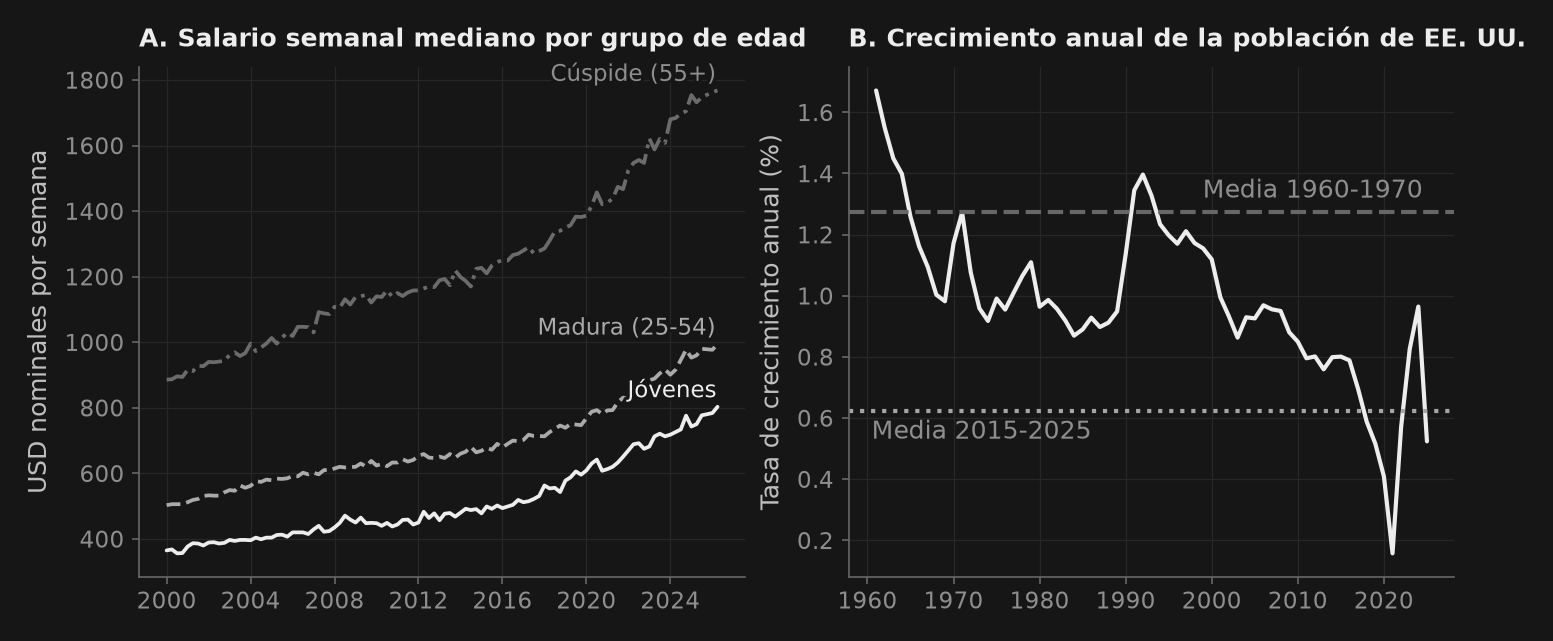

In [8]:
# ------------------------------------------------------------------------------
# Tarea 1: Carga de Datos Empíricos (BLS y Población de EE. UU.) y Calibración
# ------------------------------------------------------------------------------
# Cargar series trimestrales del BLS de salarios semanales medianos por grupo
df_young = pd.read_csv(DATOS / "LEU0252916700Q.csv", parse_dates=["observation_date"]).dropna()
df_prime = pd.read_csv(DATOS / "LEU0252917300Q.csv", parse_dates=["observation_date"]).dropna()
df_mature = pd.read_csv(DATOS / "LEU0252918500Q.csv", parse_dates=["observation_date"]).dropna()

# Cargar serie anual de población total de EE. UU.
df_pop = pd.read_csv(DATOS / "POPTOTUSA647NWDB.csv", parse_dates=["observation_date"]).dropna()

# Calcular ratios empíricos de ingreso laboral entre etapas de la carrera
earn_y_latest = df_young["LEU0252916700Q"].iloc[-1]
earn_p_latest = df_prime["LEU0252917300Q"].iloc[-1]
earn_m_latest = df_mature["LEU0252918500Q"].iloc[-1]

ratio_prime_to_young = earn_p_latest / earn_y_latest
ratio_mature_to_young = earn_m_latest / earn_y_latest

# Calcular desaceleración histórica del crecimiento demográfico de EE. UU.
df_pop["pop_growth"] = df_pop["POPTOTUSA647NWDB"].pct_change()
g_pop_1960s = df_pop.loc[df_pop["observation_date"].dt.year.between(1960, 1970), "pop_growth"].mean()
g_pop_recent = df_pop.loc[df_pop["observation_date"].dt.year.between(2015, 2025), "pop_growth"].mean()

print("--- Carga de Datos Empíricos y Calibración ---")
print(f"Salarios Semanales Recientes: Inicial/Jóvenes=${earn_y_latest:.0f} | Mediana Madura=${earn_p_latest:.0f} | Cúspide/Mayor=${earn_m_latest:.0f}")
print(f"Ratios Salariales Empíricos: Madura/Jóvenes = {ratio_prime_to_young:.2f}x | Cúspide/Jóvenes = {ratio_mature_to_young:.2f}x")
print(f"Crecimiento Demográfico Anual en EE. UU.: Promedio 1960s = {g_pop_1960s:.2%} | Promedio Reciente (2015-2025) = {g_pop_recent:.2%}")
print(f"Ratio Pico de Productividad del Modelo (kappa_20 / kappa_0) = {np.exp(0.1*20 - 0.0025*20**2):.2f}x")

# Visualizar tendencias empíricas salariales y crecimiento poblacional
fig, (ax_e, ax_p) = _nbstyle.figura(1, 2)

ax_e.plot(df_young["observation_date"], df_young["LEU0252916700Q"], label="Jóvenes", lw=1.8, ls="-", color=cols[0])
ax_e.plot(df_prime["observation_date"], df_prime["LEU0252917300Q"], label="Madura (25-54)", lw=1.8, ls="--", color=cols[1])
ax_e.plot(df_mature["observation_date"], df_mature["LEU0252918500Q"], label="Cúspide (55+)", lw=1.8, ls="-.", color=cols[2])
ax_e.set_ylabel("USD nominales por semana")
ax_e.set_title("A. Salario semanal mediano por grupo de edad")
_nbstyle.etiquetar(ax_e, donde="fin")

ax_p.plot(df_pop["observation_date"], df_pop["pop_growth"] * 100, lw=2, ls="-", color=_nbstyle.TINTA)
ax_p.axhline(g_pop_1960s * 100, color=_nbstyle.SPINE, ls="--")
ax_p.axhline(g_pop_recent * 100, color=_nbstyle.S2["color"], ls=":")
ax_p.set_ylabel("Tasa de crecimiento anual (%)")
ax_p.set_title("B. Crecimiento anual de la población de EE. UU.")
ax_p.annotate("Media 1960-1970",
              xy=(df_pop["observation_date"].iloc[-1], g_pop_1960s * 100),
              xytext=(-2, 4), textcoords="offset points", ha="right", va="bottom",
              color=_nbstyle.NOTA)
ax_p.annotate("Media 2015-2025",
              xy=(df_pop["observation_date"].iloc[0], g_pop_recent * 100),
              xytext=(2, -4), textcoords="offset points", ha="left", va="top",
              color=_nbstyle.NOTA)

plt.show()


### Tareas 2–5: Proyección Demográfica, Contabilidad del Déficit de Reparto y el Trilema de Solvencia

Implementamos la transición demográfica cuantitativa y el algoritmo de contabilidad actuarial:

1. **Regímenes Demográficos**:
   - **Demografía Inicial (Línea Base)**: Supervivencia $s_j^{\text{base}} = \text{clip}(1.0 - 0.0015 j, 0.85, 1.0)$, crecimiento poblacional $n_{\text{base}} = 0.01$ (1% anual).
   - **Choque de Envejecimiento Demográfico**: Incremento de longevidad $\tilde{s}_j = \text{clip}(1.0 - 0.0005 j, 0.92, 1.0)$, colapso de fecundidad $\tilde{n} = -0.005$ (-0.5% anual).
   - La edad de jubilación inicial es $J_R = 30$ (edad cronológica ~55 en el modelo).

2. **Tasa de Dependencia y Ponderadores de Cohorte**:
   $$\ell_0 = 1, \quad \ell_{j+1} = \ell_j \frac{s_j}{1+n}, \quad w_j = \frac{\ell_j}{\sum_{k=0}^{J-1} \ell_k}, \qquad \text{OADR} = \frac{\sum_{j=J_R}^{J-1} w_j}{\sum_{j=0}^{J_R-1} w_j}.$$

3. **Contabilidad Fiscal de Reparto (PAYGO)**:
   - Recaudación contributiva: $\text{Rev} = \tau \sum_{j=0}^{J_R-1} w_j \kappa_j$.
   - Gasto en prestaciones: $\text{Exp} = \theta \sum_{j=J_R}^{J-1} w_j$.
   - El saldo inicial se calibra a cero con tasa de reemplazo $\theta = 0.40$, fijando $\tau_{\text{base}}$.
   - Bajo envejecimiento demográfico $\tilde{w}_j$, cuantificamos el déficit estructural: $\text{Deficit}_{\text{aged}} = \text{Exp}(\tilde{w}) - \text{Rev}(\tilde{w}) > 0$.

4. **Palancas de Solvencia del Trilema**:
   - **Palanca 1 (Alza de Cotización $\tau^*$)**: $\tau^* = \theta \cdot \frac{\sum_{j=J_R}^{J-1} \tilde{w}_j}{\sum_{j=0}^{J_R-1} \tilde{w}_j \kappa_j}$.
   - **Palanca 2 (Recorte de Beneficio $\theta^*$)**: $\theta^* = \tau_{\text{base}} \cdot \frac{\sum_{j=0}^{J_R-1} \tilde{w}_j \kappa_j}{\sum_{j=J_R}^{J-1} \tilde{w}_j}$.
   - **Palanca 3 (Ampliación de Edad de Retiro $J_R^*$)**: Mínimo $J_R^* > J_R$ tal que $\text{Rev}(\tilde{w}, J_R^*) \ge \text{Exp}(\tilde{w}, J_R^*)$.

5. **Retroalimentación sobre el Capital Macroeconómico**:
   - Cómputo del capital agregado per cápita: $K = \sum_j w_j a_j$ frente a $\tilde{K} = \sum_j \tilde{w}_j a_j$.

RESULTADOS DE LA SIMULACIÓN: ENVEJECIMIENTO DEMOGRÁFICO Y SOLVENCIA PAYGO
Tasa de Dependencia de la Vejez (OADR): Base = 0.1352  -->  Envejecida = 0.2944 (+117.7%)
Balance Fiscal Inicial de Reparto:      Ingresos = 0.0476, Gastos = 0.0476 (Equilibrado = 0.000000)
Estado Previsional Post-Choque:         Ingresos = 0.0439, Gastos = 0.0910 --> Déficit = 0.0471 (51.8% del gasto)
Palanca de Política 1 (Alza Impositiva): tau: 0.0262 --> tau* = 0.0543 (+107.3%)
Palanca de Política 2 (Corte Beneficio): theta: 0.4000 --> theta* = 0.1930 (-51.8%)
Palanca de Política 3 (Edad Jubilación): J_R: 30 --> J_R* = 35 (+5 años de modelo)
Impacto en Capital Macroeconómico:       K_base = 2.5107 --> K_envejecido = 3.4687 (+38.2%)


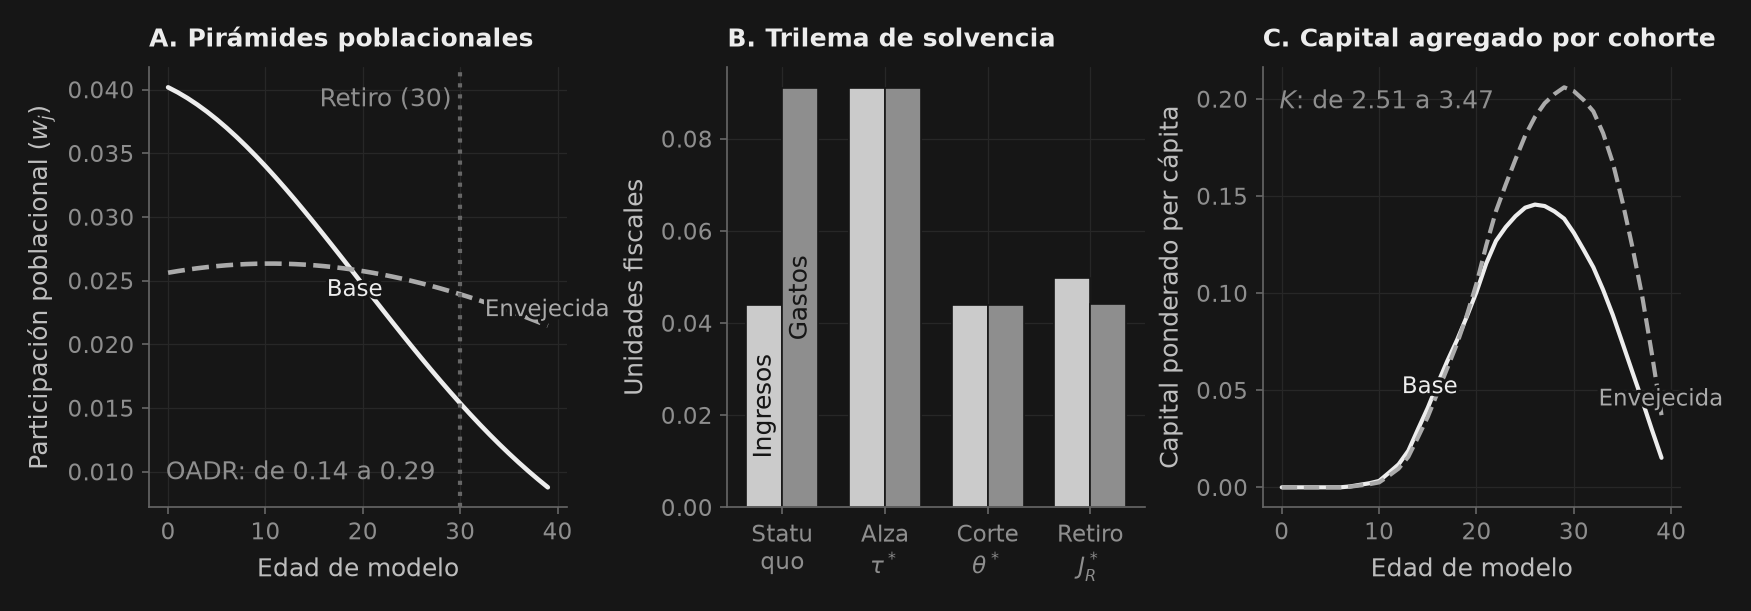

In [9]:
# ------------------------------------------------------------------------------
# Tareas 2–5: Proyección Demográfica, Desbalance Fiscal y Trilema de Políticas
# ------------------------------------------------------------------------------
J_R_base = 30                                           # Edad modelo de jubilación base
theta_base = 0.40                                       # Tasa de reemplazo base (40% del salario medio)

# Tarea 2: Cómputo de Ponderadores Demográficos de Línea Base
s_base = np.clip(1.0 - 0.0015 * age, 0.85, 1.0)
n_base = 0.01
ell_base = np.zeros(J); ell_base[0] = 1.0
for k in range(J - 1):
    ell_base[k + 1] = ell_base[k] * s_base[k] / (1.0 + n_base)
w_base = ell_base / ell_base.sum()

# Tarea 2: Ponderadores Demográficos bajo Envejecimiento (Mayor Longevidad y Caída de Fecundidad)
s_aged = np.clip(1.0 - 0.0005 * age, 0.92, 1.0)
n_aged = -0.005
ell_aged = np.zeros(J); ell_aged[0] = 1.0
for k in range(J - 1):
    ell_aged[k + 1] = ell_aged[k] * s_aged[k] / (1.0 + n_aged)
w_aged = ell_aged / ell_aged.sum()

# Tasas de Dependencia de la Vejez (OADR)
oadr_base = float(w_base[J_R_base:].sum() / w_base[:J_R_base].sum())
oadr_aged = float(w_aged[J_R_base:].sum() / w_aged[:J_R_base].sum())

# Tarea 3: Contabilidad Fiscal del Sistema de Reparto (PAYGO)
eff_labor_base = float((w_base[:J_R_base] * kappa_profile[:J_R_base]).sum())
retirees_base = float(w_base[J_R_base:].sum())
tau_base = float(theta_base * retirees_base / eff_labor_base)

rev_base = tau_base * eff_labor_base
exp_base = theta_base * retirees_base
balance_base = rev_base - exp_base

# Déficit Estructural bajo Choque de Envejecimiento (Política Inalterada)
eff_labor_aged = float((w_aged[:J_R_base] * kappa_profile[:J_R_base]).sum())
retirees_aged = float(w_aged[J_R_base:].sum())
rev_aged = tau_base * eff_labor_aged
exp_aged = theta_base * retirees_aged
deficit_aged = float(exp_aged - rev_aged)

# Tarea 4: Trilema de Políticas de Solvencia
# Palanca 1: Tasa de Cotización Requerida para Solvencia
tau_solvency = float(theta_base * retirees_aged / eff_labor_aged)

# Palanca 2: Tasa de Reemplazo Requerida con Cotización Fija
theta_solvency = float(tau_base * eff_labor_aged / retirees_aged)

# Palanca 3: Postergación de la Edad de Jubilación Requerida
J_R_solvency = J_R_base
for jr in range(J_R_base, J):
    rev_test = tau_base * (w_aged[:jr] * kappa_profile[:jr]).sum()
    exp_test = theta_base * w_aged[jr:].sum()
    if rev_test >= exp_test:
        J_R_solvency = jr
        break

# Tarea 5: Retroalimentación Macroeconómica sobre el Capital Agregado
K_base = float(np.sum(w_base * assets_by_age))
K_aged = float(np.sum(w_aged * assets_by_age))

print("================================================================================")
print("RESULTADOS DE LA SIMULACIÓN: ENVEJECIMIENTO DEMOGRÁFICO Y SOLVENCIA PAYGO")
print("================================================================================")
print(f"Tasa de Dependencia de la Vejez (OADR): Base = {oadr_base:.4f}  -->  Envejecida = {oadr_aged:.4f} (+{(oadr_aged/oadr_base - 1):.1%})")
print(f"Balance Fiscal Inicial de Reparto:      Ingresos = {rev_base:.4f}, Gastos = {exp_base:.4f} (Equilibrado = {balance_base:.6f})")
print(f"Estado Previsional Post-Choque:         Ingresos = {rev_aged:.4f}, Gastos = {exp_aged:.4f} --> Déficit = {deficit_aged:.4f} ({deficit_aged/exp_aged:.1%} del gasto)")
print(f"Palanca de Política 1 (Alza Impositiva): tau: {tau_base:.4f} --> tau* = {tau_solvency:.4f} (+{(tau_solvency/tau_base - 1):.1%})")
print(f"Palanca de Política 2 (Corte Beneficio): theta: {theta_base:.4f} --> theta* = {theta_solvency:.4f} (-{(1 - theta_solvency/theta_base):.1%})")
print(f"Palanca de Política 3 (Edad Jubilación): J_R: {J_R_base} --> J_R* = {J_R_solvency} (+{J_R_solvency - J_R_base} años de modelo)")
print(f"Impacto en Capital Macroeconómico:       K_base = {K_base:.4f} --> K_envejecido = {K_aged:.4f} (+{(K_aged/K_base - 1):.1%})")
print("================================================================================")

# Aserciones de Verificación Objetiva (Controles de Integridad Obligatorios)
assert oadr_aged >= 1.40 * oadr_base, f"Choque demográfico insuficiente: {oadr_aged} vs {oadr_base}"
assert deficit_aged > 0.0, "El envejecimiento debe generar déficit fiscal bajo parámetros fijos"
assert tau_solvency > tau_base, f"La tasa de cotización de solvencia {tau_solvency} <= {tau_base}"
assert J_R_solvency > J_R_base, f"La edad de jubilación de solvencia {J_R_solvency} <= {J_R_base}"
assert np.isclose(w_aged.sum(), 1.0), "Los ponderadores demográficos envejecidos deben sumar exactamente 1.0"

# ------------------------------------------------------------------------------
# Visualización Macroeconómica y de Políticas en 3 Paneles
# ------------------------------------------------------------------------------
fig, (ax1, ax2, ax3) = _nbstyle.figura(1, 3)

# Panel A: Pirámides Demográficas
ax1.plot(age, w_base, color=cols[0], lw=2.2, ls="-", label="Base")
ax1.plot(age, w_aged, color=cols[1], lw=2.2, ls="--", label="Envejecida")
ax1.axvline(J_R_base, color=_nbstyle.SPINE, ls=":")
ax1.set_xlabel("Edad de modelo")
ax1.set_ylabel("Participación poblacional ($w_j$)")
ax1.set_title("A. Pirámides poblacionales")
ax1.annotate(f"OADR: de {oadr_base:.2f} a {oadr_aged:.2f}", xy=(0.04, 0.05),
             xycoords="axes fraction", ha="left", va="bottom", color=_nbstyle.NOTA)
ax1.annotate(f"Retiro ({J_R_base})", xy=(J_R_base, w_base.max()), xytext=(-4, 0),
             textcoords="offset points", ha="right", va="top", color=_nbstyle.NOTA)
_nbstyle.etiquetar(ax1)

# Panel B: El Trilema de Solvencia de Reparto
levers = ["Statu\nquo", "Alza\n$\\tau^*$", "Corte\n$\\theta^*$", "Retiro\n$J_R^*$"]
revenues = [rev_aged, tau_solvency * eff_labor_aged, rev_aged, tau_base * (w_aged[:J_R_solvency] * kappa_profile[:J_R_solvency]).sum()]
outlays = [exp_aged, exp_aged, theta_solvency * retirees_aged, theta_base * w_aged[J_R_solvency:].sum()]
x_idx = np.arange(len(levers))
width = 0.35

ax2.bar(x_idx - width/2, revenues, width, color=_nbstyle.BARRA_COLORES[0], edgecolor=_nbstyle.FONDO, lw=0.8)
ax2.bar(x_idx + width/2, outlays, width, color=_nbstyle.BARRA_COLORES[1], edgecolor=_nbstyle.FONDO, lw=0.8)
ax2.text(x_idx[0] - width/2, revenues[0] / 2, "Ingresos", rotation=90,
         ha="center", va="center", color=_nbstyle.FONDO)
ax2.text(x_idx[0] + width/2, outlays[0] / 2, "Gastos", rotation=90,
         ha="center", va="center", color=_nbstyle.FONDO)
ax2.set_xticks(x_idx)
ax2.set_xticklabels(levers)
ax2.set_ylabel("Unidades fiscales")
ax2.set_title("B. Trilema de solvencia")

# Panel C: Capital Ponderado por Cohortes
ax3.plot(age, w_base * assets_by_age, color=cols[0], lw=2.0, ls="-", label="Base")
ax3.plot(age, w_aged * assets_by_age, color=cols[1], lw=2.0, ls="--", label="Envejecida")
ax3.set_xlabel("Edad de modelo")
ax3.set_ylabel("Capital ponderado per cápita")
ax3.set_title("C. Capital agregado por cohorte")
ax3.annotate(f"$K$: de {K_base:.2f} a {K_aged:.2f}", xy=(0.04, 0.95),
             xycoords="axes fraction", ha="left", va="top", color=_nbstyle.NOTA)
_nbstyle.etiquetar(ax3)

plt.show()


### Evaluación de Políticas y Distribución Intergeneracional

Los resultados cuantitativos derivados de la simulación exponen con claridad el dilema distributivo intergeneracional intrínseco a la reforma previsional:

1. **Magnitud del Choque Demográfico**:
   La conjunción de menor dinamismo poblacional ($n = -0.5\%$) y mayor longevidad eleva la Tasa de Dependencia de la Vejez (OADR) de **0.135** a **0.294**, lo que representa algo más que una duplicación (+118%). Sin reformas paramétricas, el déficit previsional alcanza el 51.8% del gasto en pensiones, abriendo una severa brecha fiscal.

2. **Evaluación de las Palancas de Solvencia**:
   - **Palanca 1 (Alza Impositiva $\tau \to \tau^*$ = 5.43%)**: Equilibrar las cuentas públicas únicamente mediante cotizaciones exige más que duplicar el tipo gravamen sobre la nómina, pasando de 2.62% a 5.43% (+107%). En economías reales donde las cotizaciones iniciales rondan el 12–15%, una duplicación similar provocaría graves pérdidas de eficiencia económica sobre el empleo, desincentivaría el trabajo formal y cargaría todo el ajuste sobre las cohortes jóvenes y no nacidas.
   - **Palanca 2 (Recorte de la Tasa de Reemplazo $\theta \to \theta^*$ = 19.3%)**: Reducir la prestación a menos de la mitad (de 40% a 19.3%) traslada la carga íntegra sobre los jubilados, vulnerando la seguridad económica en la tercera edad y disparando el riesgo de pobreza extrema entre los ancianos.
   - **Palanca 3 (Ampliación de la Edad de Jubilación $J_R \to J_R^*$ = 35)**: Aumentar la edad legal de retiro en 5 años de modelo restablece el equilibrio presupuestario sin tocar las pensiones mensuales ni incrementar las tasas impositivas. Esta medida opera simultáneamente sobre los dos brazos de la tijera fiscal: transforma a 5 cohortes de perceptores pasivos en cotizantes productivos.

3. **Profundización del Capital en la Transición Demográfica**:
   Observe que el capital agregado per cápita se eleva de $K = 2.51$ a $\tilde{K} = 3.47$ (+38.2%). Dado que los trabajadores maduros y los jubilados recientes acumulan los mayores saldos de activos, el desplazamiento de la masa poblacional hacia cohortes de mayor edad profundiza transitoriamente el capital agregado. En equilibrio general, esta mayor intensidad de capital tiende a deprimir el rendimiento real del capital $r$ y elevar los salarios reales $w$, generando efectos dinámicos que amortiguan parcialmente la tensión presupuestaria (Auerbach & Kotlikoff 1987).

## 5. Conclusión Profesoral: Demografía, Arquitectura Previsional y Política Macroeconómica

En este módulo, hemos examinado la arquitectura analítica y computacional de la macroeconomía del ciclo de vida con horizonte finito y sus implicaciones para las finanzas públicas y los sistemas previsionales.

### Lecciones Fundamentales

1. **Acumulación del Ciclo Vital vs. Ahorro Precautorio**:
   La tenencia agregada de riqueza en la economía no es únicamente un colchón frente a choques transitorios; es ante todo un puente intertemporal a lo largo del ciclo vital. La interacción entre una productividad laboral con forma de joroba, restricciones al endeudamiento ($a' \ge 0$) y un horizonte temporal finito genera de forma endógena la curva jorobada de riqueza observada en los datos microeconómicos de hogares.

2. **La Fragilidad del Reparto ante la Condición de Aaron (1966)**:
   Los sistemas de reparto son contratos biológicos intergeneracionales cuya tasa de rendimiento está acotada por la suma del crecimiento demográfico y de la productividad ($n + g$). Cuando la longevidad aumenta y la fecundidad disminuye, los sistemas de reparto incurren inevitablemente en déficits estructurales a menos que se ajusten las palancas del trilema previsional.

3. **Mecanismos de Ajuste Automático y Diseño Institucional**:
   Las reformas previsionales contemporáneas abandonan gradualmente los esquemas tradicionales de beneficio definido para adoptar sistemas de **Cuentas Nocionales de Contribución Definida (NDC)** (como en Suecia o Italia) o indexar automáticamente la edad de jubilación a la esperanza de vida de la cohorte (como en Dinamarca, Finlandia o los Países Bajos). Estas reglas permiten despolitizar el debate previsional y restablecer la solvencia actuarial de manera automática.

4. **Líneas de Investigación en la Frontera**:
   - **Oferta Laboral Endógena y Retiro Gradual**: Modelar la decisión de horas y la edad óptima de jubilación en respuesta a impuestos marginales y fórmulas de cómputo previsional (Prescott 2004, Rogerson & Wallenius 2009).
   - **Riesgo de Salud y Gastos Médicos Catastróficos en la Vejez**: Incorporar la incertidumbre en gastos sanitarios tardíos, lo cual frena la desacumulación de activos en los ancianos y genera herencias accidentales sustanciales (De Nardi, French & Jones 2010).
   - **Transiciones Dinámicas OLG en Equilibrio General**: Resolver la senda de transición intertemporal de precios de factores ($r_t, w_t$) durante el envejecimiento demográfico aplicando algoritmos de relajación de Gauss-Seidel al estilo de Auerbach y Kotlikoff (1987).